<a href="https://www.kaggle.com/code/mrafraim/dl-day-44-cnn-advanced-mini-project-f-mnist?scriptVersionId=306368041" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Day 44: CNN Advanced Mini Project

***Dataset:** Fashion-MNIST*

***Goal:** Build • Understand • Diagnose • Improve*

Welcome to Day 44!

Today You’ll Learn

1. How to design a CNN pipeline from first principles  
2. How each component affects training behavior  
3. How to read loss/accuracy curves like a professional  
4. How to diagnose overfitting vs underfitting  
5. How to run controlled experiments  

If you found this notebook helpful, your **<b style="color:skyblue;">UPVOTE</b>** would be greatly appreciated! It helps others discover the work and supports continuous improvement.

---

# Mental Model (Before Coding)

A CNN pipeline has 5 controllable systems:

1. Data → what model sees  
2. Model → capacity to learn  
3. Optimization → how it learns  
4. Regularization → prevents memorization  
5. Evaluation → tells truth  

👉 If model fails → one of these is broken

# Imports

In [1]:
# ================================
# Core Deep Learning Libraries
# ================================

import torch                                  # Main PyTorch library (tensor operations + GPU support)
import torch.nn as nn                         # Neural network module (layers, loss functions, etc.)
import torch.optim as optim                   # Optimization algorithms (SGD, Adam, etc.)


# ==========================================
# Dataset Handling & Image Transformations
# ==========================================

import torchvision                           # Built-in datasets (MNIST, CIFAR, etc.)
import torchvision.transforms as transforms  # Used to preprocess images (normalization, augmentation, tensor conversion)


# ==========================
# Data Loading Utilities
# ==========================

from torch.utils.data import DataLoader      # Efficient batching, shuffling, and parallel data loading


# ==========================
# Visualization
# ==========================

import matplotlib.pyplot as plt             # Used to visualize images, training curves, predictions


# =====================================
# Reproducibility & Random Control
# =====================================

import numpy as np                          # Numerical operations (used in preprocessing, metrics)
import random                               # Python's built-in random generator


# ====================
# Fix Random Seeds
# ====================

# Why this matters:
# Deep learning involves randomness in:
# - Weight initialization
# - Data shuffling
# - Dropout layers
# Without fixing seeds, results will vary every run → bad for debugging & reproducibility

torch.manual_seed(42)                     # Fix PyTorch randomness (CPU + partially GPU)
np.random.seed(42)                        # Fix NumPy randomness
random.seed(42)                           # Fix Python random module

# Fashion-MNIST Dataset Overview

Fashion-MNIST is a dataset released by Zalando Research on GitHub.  
It consists of 28x28 grayscale images of fashion items and is widely used for benchmarking image classification models.

### Key Features & Structure

- **Categories:** 10 classes representing clothes, shoes, and bags.  
- **Dimensions:** 28x28 grayscale pixels → 784 features per image.  
- **Size:**  
  - Training set: 60,000 images  
  - Test/Validation set: 10,000 images  
- **Data Format:**  
  - Images: `uint8` numpy arrays  
  - Labels: integers `0-9` corresponding to classes  


### <p style="text-align:center;">Class Labels</p>

| Label | Category        |
|-------|----------------|
| 0     | T-shirt/top     |
| 1     | Trouser         |
| 2     | Pullover        |
| 3     | Dress           |
| 4     | Coat            |
| 5     | Sandal          |
| 6     | Shirt           |
| 7     | Sneaker         |
| 8     | Bag             |
| 9     | Ankle boot      |

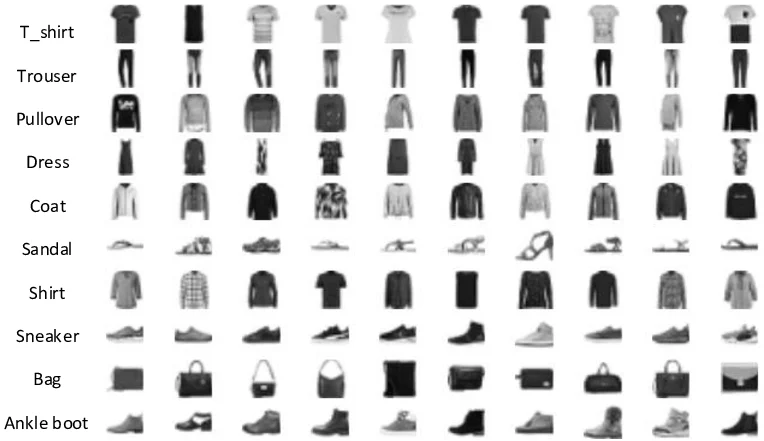

# Data Strategy

The quality and strategy of our data pipeline often contributes more to model performance than architecture tweaks.

### Strategy Decision

We aren't just loading images; we are preparing the pipeline. Our strategy focuses on two key pillars:

- **Generalization:** By adding a slight rotation to the training images, we teach the model that a "shirt" is still a "shirt" even if it's slightly tilted.
- **Stability:** We use normalization to ensure the pixel values (originally 0-255) are scaled to a range that helps the neural network converge faster and more reliably.


### Why Separate Transformations?

- **Training (`transform_train`):** Includes "Augmentation." We want the model to see a slightly different version of the data in every epoch to prevent overfitting.
- **Validation (`transform_val`):** No augmentation. We need a clean, objective "ruler" to measure how the model performs on real-world, centered data.

In [2]:
# ------------------------------
# Training Data Transformations
# ------------------------------

# Goal: introduce slight variation while keeping label semantics intact

transform_train = transforms.Compose([
    transforms.RandomRotation(10),       # Randomly rotate images by ±10 degrees → small augmentation for generalization
    transforms.ToTensor(),               # Convert PIL image to PyTorch tensor (0-1 scale)
    transforms.Normalize((0.5,), (0.5,)) # Normalize to mean=0.5, std=0.5 → stabilizes gradients
])

# ------------------------------
# Validation Data Transformations
# ------------------------------

# Goal: reflect real-world distribution --> NO augmentation

transform_val = transforms.Compose([
    transforms.ToTensor(),               # Convert image to tensor
    transforms.Normalize((0.5,), (0.5,)) # Normalize same as training
])

TO BE CONTINUE....

---
<p style="text-align:center; color:skyblue; font-size:18px;">
© 2026 Mostafizur Rahman
</p>
